---
# Notebook 03 — Multiclass Classification (8 subtypes)

---

**Context**
Notebook 02 selected ResNet50 for binary classification based on clinical safety:

| Model | AUC | False Negatives | Decision |
|---|---|---|---|
| ResNet50 | 0.908 | 124 | selected |
| EfficientNet-B3 | 0.923 | 179 | rejected |
| DenseNet121 | 0.898 | 183 | rejected |

**Why different models here**
The 8-class problem requires fine-grained separation of morphologically similar
subtypes. EfficientNet-B3's higher AUC and discriminative capacity suit this better.
ResNet50's binary weakness was specific to the class imbalance in that task.

**Experiments in this notebook**
1. ResNet50 — baseline multiclass (transfer learning, frozen early layers)
2. EfficientNet-B3 — improved augmentation, layerwise LR, cosine schedule
3. Phikon-v2 — histopathology foundation model, partial fine-tuning (last 2 transformer blocks)

**Key fix vs previous versions:** stratified image-level split — guarantees all 8 subtypes
are present in train/val/test at proportional rates.

In [1]:
import os
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        if f.endswith('.pth'):
            print(os.path.join(root, f))

/kaggle/input/notebooks/megixibrraku/breakhis-02-binary/checkpoints/best_densenet121_binary.pth
/kaggle/input/notebooks/megixibrraku/breakhis-02-binary/checkpoints/best_efficientnet_b3_binary.pth
/kaggle/input/notebooks/megixibrraku/breakhis-02-binary/checkpoints/best_resnet50_binary.pth


In [2]:
# Cell 1 — imports & paths
import os, random, time, copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, f1_score)
from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

NB1_OUTPUT = '/kaggle/input/notebooks/megixibrraku/breakhis-01-eda'
NB2_OUTPUT = '/kaggle/input/notebooks/megixibrraku/breakhis-02-binary'

os.makedirs('/kaggle/working/checkpoints', exist_ok=True)
os.makedirs('/kaggle/working/figures',     exist_ok=True)

Device: cuda


In [3]:
# Cell 2 — stratified split (fixed)
# Image-level stratified split — guarantees all 8 subtypes in every fold
# Patient leakage is acceptable for a course project
full_df = pd.read_csv(f'{NB1_OUTPUT}/splits/full_df.csv')

train_df, temp_df = train_test_split(
    full_df,
    test_size=0.3,
    random_state=SEED,
    stratify=full_df['subtype_label']
)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=SEED,
    stratify=temp_df['subtype_label']
)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

# subtype mapping
subtype_map = pd.read_csv(f'{NB1_OUTPUT}/splits/subtype_mapping.csv')
subtype2idx = dict(zip(subtype_map['subtype'], subtype_map['label']))
idx2subtype = {v: k for k, v in subtype2idx.items()}
class_names = [idx2subtype[i] for i in range(len(idx2subtype))]
NUM_CLASSES = len(class_names)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print(f"Classes: {NUM_CLASSES}")
print("\nTRAIN distribution:")
print(train_df['subtype_label'].value_counts().sort_index())
print("\nVAL distribution:")
print(val_df['subtype_label'].value_counts().sort_index())
print("\nTEST distribution:")
print(test_df['subtype_label'].value_counts().sort_index())

Train: 5536 | Val: 1186 | Test: 1187
Classes: 8

TRAIN distribution:
subtype_label
0     311
1    2416
2     710
3     438
4     554
5     392
6     317
7     398
Name: count, dtype: int64

VAL distribution:
subtype_label
0     67
1    517
2    152
3     94
4    119
5     84
6     68
7     85
Name: count, dtype: int64

TEST distribution:
subtype_label
0     66
1    518
2    152
3     94
4    119
5     84
6     68
7     86
Name: count, dtype: int64


In [4]:
# Cell 3 — dataset class & loaders
# Single transform set used by all experiments — richer augmentation
class BreakHisDataset(Dataset):
    def __init__(self, df, transform=None, label_col='subtype_label'):
        self.df        = df.reset_index(drop=True)
        self.transform = transform
        self.label_col = label_col

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        img   = Image.open(row['path']).convert('RGB')
        label = int(row[self.label_col])
        if self.transform: img = self.transform(img)
        return img, label

    def get_pil(self, idx):
        return Image.open(self.df.iloc[idx]['path']).convert('RGB')

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.05),
    transforms.RandomAffine(degrees=0, shear=10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

train_ds = BreakHisDataset(train_df, train_transform)
val_ds   = BreakHisDataset(val_df,   val_transform)
test_ds  = BreakHisDataset(test_df,  val_transform)

# batch_size=32 and num_workers=2 throughout — faster than the original 16/0
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=2)

print("Datasets ready.")
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Datasets ready.
Train batches: 173 | Val batches: 38


In [5]:
# Cell 4 — shared weighted loss criterion
counts   = train_df['subtype_label'].value_counts().sort_index()
total    = len(train_df)
weights  = torch.tensor(
    [total / (NUM_CLASSES * counts[i]) for i in range(NUM_CLASSES)],
    dtype=torch.float
).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=weights)

print("Class weights:")
for i, w in enumerate(weights.cpu().numpy()):
    print(f"  {class_names[i]:25s} {w:.3f}")

Class weights:
  adenosis                  2.225
  ductal_carcinoma          0.286
  fibroadenoma              0.975
  lobular_carcinoma         1.580
  mucinous_carcinoma        1.249
  papillary_carcinoma       1.765
  phyllodes_tumor           2.183
  tubular_adenoma           1.739


---
# EXPERIMENT 1 — ResNet50

Baseline: ResNet50 with frozen early layers, only layer3 + layer4 + classifier trained.
Dropout before classifier to reduce overfitting.

In [6]:
# Cell 5 — ResNet50 model
def build_resnet(num_classes=8):
    model = models.resnet50(weights='IMAGENET1K_V2')
    # freeze early layers, train only last 2 blocks
    for param in model.parameters():
        param.requires_grad = False
    for param in model.layer3.parameters():
        param.requires_grad = True
    for param in model.layer4.parameters():
        param.requires_grad = True
    model.fc = nn.Sequential(
        nn.Dropout(p=0.5),
        nn.Linear(model.fc.in_features, num_classes)
    )
    return model.to(DEVICE)

In [7]:
# Cell 6 — ResNet50 training loop
def train_resnet(num_epochs=20, save_name='resnet_multiclass'):
    model     = build_resnet(NUM_CLASSES)
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=1e-4, weight_decay=1e-3
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-6)

    best_val_f1  = 0.0
    best_weights = None
    history      = {'train_loss': [], 'val_loss': [], 'val_f1': []}

    for epoch in range(num_epochs):
        t0 = time.time()
        model.train()
        running_loss = 0.0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(imgs), labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * imgs.size(0)
        train_loss = running_loss / len(train_ds)

        model.eval()
        val_loss, all_preds, all_labels = 0.0, [], []
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                outputs      = model(imgs)
                val_loss    += criterion(outputs, labels).item() * imgs.size(0)
                all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        val_loss /= len(val_ds)
        val_f1    = f1_score(all_labels, all_preds, average='macro')
        scheduler.step()

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_f1'].append(val_f1)

        if val_f1 > best_val_f1:
            best_val_f1  = val_f1
            best_weights = copy.deepcopy(model.state_dict())
            torch.save(best_weights,
                f'/kaggle/working/checkpoints/best_{save_name}.pth')
            print(f"  --> checkpoint saved (F1: {val_f1:.4f})")

        if (epoch + 1) % 5 == 0:
            per_class = f1_score(all_labels, all_preds, average=None)
            print("  Per-class F1:")
            for i, f in enumerate(per_class):
                print(f"    {class_names[i]:25s} {f:.4f}")

        print(f"Epoch {epoch+1}/{num_epochs} | "
              f"Train loss: {train_loss:.4f} | "
              f"Val loss: {val_loss:.4f} | "
              f"Val macro-F1: {val_f1:.4f} | "
              f"{int(time.time()-t0)}s")

    model.load_state_dict(best_weights)
    print(f"\nBest Val macro-F1: {best_val_f1:.4f}")
    return model, history

In [8]:
# Cell 7 — Train ResNet50
print("=== Training ResNet50 — 8-class multiclass ===")
resnet_model, resnet_history = train_resnet(
    num_epochs=20,
    save_name='resnet_multiclass_fixed'
)

=== Training ResNet50 — 8-class multiclass ===
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 241MB/s]


  --> checkpoint saved (F1: 0.5089)
Epoch 1/20 | Train loss: 1.7936 | Val loss: 1.2582 | Val macro-F1: 0.5089 | 106s
  --> checkpoint saved (F1: 0.6985)
Epoch 2/20 | Train loss: 1.1136 | Val loss: 0.7768 | Val macro-F1: 0.6985 | 73s
  --> checkpoint saved (F1: 0.7606)
Epoch 3/20 | Train loss: 0.8087 | Val loss: 0.5440 | Val macro-F1: 0.7606 | 74s
  --> checkpoint saved (F1: 0.7964)
Epoch 4/20 | Train loss: 0.6620 | Val loss: 0.4904 | Val macro-F1: 0.7964 | 76s
  --> checkpoint saved (F1: 0.8332)
  Per-class F1:
    adenosis                  0.9209
    ductal_carcinoma          0.8553
    fibroadenoma              0.8924
    lobular_carcinoma         0.6437
    mucinous_carcinoma        0.8392
    papillary_carcinoma       0.8333
    phyllodes_tumor           0.7656
    tubular_adenoma           0.9153
Epoch 5/20 | Train loss: 0.5678 | Val loss: 0.3837 | Val macro-F1: 0.8332 | 75s
  --> checkpoint saved (F1: 0.8410)
Epoch 6/20 | Train loss: 0.4658 | Val loss: 0.3505 | Val macro-F1: 0.84

---
# EXPERIMENT 2 — EfficientNet-B3

EfficientNet-B3 with:
- Last 2 MBConv blocks unfrozen
- Layerwise learning rates (backbone 1e-5, classifier 1e-3)
- Cosine annealing schedule
- Early stopping (patience=5)
- Richer augmentation (already set in Cell 3)

In [9]:
# Cell 8 — EfficientNet-B3 model
def build_efficientnet(num_classes=8):
    model = models.efficientnet_b3(weights='IMAGENET1K_V1')
    for param in model.parameters():
        param.requires_grad = False
    # unfreeze last 2 MBConv blocks
    for param in model.features[7].parameters():
        param.requires_grad = True
    for param in model.features[8].parameters():
        param.requires_grad = True
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(in_features, num_classes)
    )
    return model.to(DEVICE)

In [10]:
# Cell 9 — EfficientNet-B3 training loop
def train_efficientnet(num_epochs=20, save_name='efficientnet_multiclass', patience=5):
    model = build_efficientnet(NUM_CLASSES)
    optimizer = optim.Adam([
        {'params': model.features[7].parameters(), 'lr': 1e-5},
        {'params': model.features[8].parameters(), 'lr': 1e-5},
        {'params': model.classifier.parameters(), 'lr': 1e-3},
    ], weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-7)

    best_val_f1      = 0.0
    best_weights     = None
    patience_counter = 0
    history          = {'train_loss': [], 'val_loss': [], 'val_f1': []}

    for epoch in range(num_epochs):
        t0 = time.time()
        model.train()
        running_loss = 0.0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(imgs), labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * imgs.size(0)
        train_loss = running_loss / len(train_ds)

        model.eval()
        val_loss, all_preds, all_labels = 0.0, [], []
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                outputs   = model(imgs)
                val_loss += criterion(outputs, labels).item() * imgs.size(0)
                all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        val_loss /= len(val_ds)
        val_f1    = f1_score(all_labels, all_preds, average='macro')
        scheduler.step()

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_f1'].append(val_f1)

        if val_f1 > best_val_f1:
            best_val_f1      = val_f1
            best_weights     = copy.deepcopy(model.state_dict())
            patience_counter = 0
            torch.save(best_weights,
                f'/kaggle/working/checkpoints/best_{save_name}.pth')
            print(f"  --> checkpoint saved (F1: {val_f1:.4f})")
        else:
            patience_counter += 1

        if (epoch + 1) % 5 == 0:
            per_class = f1_score(all_labels, all_preds, average=None)
            print("  Per-class F1:")
            for i, f in enumerate(per_class):
                print(f"    {class_names[i]:25s} {f:.4f}")

        print(f"Epoch {epoch+1}/{num_epochs} | "
              f"Train loss: {train_loss:.4f} | "
              f"Val loss: {val_loss:.4f} | "
              f"Val macro-F1: {val_f1:.4f} | "
              f"{int(time.time()-t0)}s")

        if patience_counter >= patience:
            print(f"\nEarly stopping — no improvement for {patience} epochs")
            break

    model.load_state_dict(best_weights)
    print(f"\nBest Val macro-F1: {best_val_f1:.4f}")
    return model, history

In [11]:
# Cell 10 — Train EfficientNet-B3
print("=== Training EfficientNet-B3 — 8-class multiclass ===")
eff_model, eff_history = train_efficientnet(
    num_epochs=20,
    save_name='efficientnet_multiclass_fixed',
    patience=5
)

=== Training EfficientNet-B3 — 8-class multiclass ===
Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 238MB/s]


  --> checkpoint saved (F1: 0.4047)
Epoch 1/20 | Train loss: 1.8201 | Val loss: 1.5646 | Val macro-F1: 0.4047 | 69s
  --> checkpoint saved (F1: 0.4296)
Epoch 2/20 | Train loss: 1.5708 | Val loss: 1.4050 | Val macro-F1: 0.4296 | 69s
  --> checkpoint saved (F1: 0.4822)
Epoch 3/20 | Train loss: 1.4675 | Val loss: 1.3236 | Val macro-F1: 0.4822 | 70s
  --> checkpoint saved (F1: 0.5022)
Epoch 4/20 | Train loss: 1.4071 | Val loss: 1.2486 | Val macro-F1: 0.5022 | 69s
  --> checkpoint saved (F1: 0.5136)
  Per-class F1:
    adenosis                  0.5891
    ductal_carcinoma          0.6382
    fibroadenoma              0.5188
    lobular_carcinoma         0.4737
    mucinous_carcinoma        0.4661
    papillary_carcinoma       0.4321
    phyllodes_tumor           0.4889
    tubular_adenoma           0.5019
Epoch 5/20 | Train loss: 1.3640 | Val loss: 1.2370 | Val macro-F1: 0.5136 | 69s
  --> checkpoint saved (F1: 0.5275)
Epoch 6/20 | Train loss: 1.3304 | Val loss: 1.2073 | Val macro-F1: 0.527

---
# EXPERIMENT 3 — Phikon-v2 (histopathology foundation model)

Phikon-v2 is a Vision Transformer pretrained by Owkin on large-scale histopathology slides.
It produces 1024-dim CLS token features that capture tissue-level morphology.

**Approach: partial fine-tuning**
- Freeze all layers except the last 2 transformer blocks + classifier head
- This is stronger than a frozen linear probe (previous approach) but cheaper than full fine-tuning
- Separate lower LR for backbone (1e-5) vs head (1e-3)

**Important:** Phikon-v2 has its own normalization built into the processor.
We pass raw PIL images through `AutoImageProcessor` — NOT pre-normalized tensors.

In [12]:
# Cell 11 — install transformers and load Phikon-v2
!pip install transformers -q

from transformers import AutoImageProcessor, AutoModel

phikon_processor = AutoImageProcessor.from_pretrained("owkin/phikon-v2")
phikon_model     = AutoModel.from_pretrained("owkin/phikon-v2")
phikon_model     = phikon_model.to(DEVICE)

print("Phikon-v2 loaded.")
print(f"Parameters: {sum(p.numel() for p in phikon_model.parameters()):,}")
print(f"Encoder blocks: {len(phikon_model.encoder.layer)}")

preprocessor_config.json:   0%|          | 0.00/750 [00:00<?, ?B/s]

The image processor of type `BitImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.21G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/439 [00:00<?, ?it/s]

Phikon-v2 loaded.
Parameters: 303,351,808
Encoder blocks: 24


In [13]:
# Cell 12 — freeze all Phikon layers except last 2 transformer blocks
# Freeze everything first
for param in phikon_model.parameters():
    param.requires_grad = False

# Unfreeze last 2 encoder blocks
num_blocks = len(phikon_model.encoder.layer)
for block in phikon_model.encoder.layer[num_blocks - 2:]:
    for param in block.parameters():
        param.requires_grad = True

# Unfreeze layernorm at the top
if hasattr(phikon_model, 'layernorm'):
    for param in phikon_model.layernorm.parameters():
        param.requires_grad = True

trainable = sum(p.numel() for p in phikon_model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in phikon_model.parameters())
print(f"Trainable: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")

Trainable: 25,198,592 / 303,351,808 (8.3%)


In [14]:
# Cell 13 — Phikon dataset: passes raw PIL images through processor
# IMPORTANT: do NOT use the normalized tensor loader here.
# Phikon-v2's processor does its own normalization — passing pre-normalized
# tensors would double-normalize and corrupt the features.

class PhikonDataset(Dataset):
    def __init__(self, df, processor, label_col='subtype_label'):
        self.df        = df.reset_index(drop=True)
        self.processor = processor
        self.label_col = label_col

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        img   = Image.open(row['path']).convert('RGB')
        label = int(row[self.label_col])
        # processor returns a dict with 'pixel_values' tensor, correctly normalized
        inputs = self.processor(images=img, return_tensors='pt')
        pixel_values = inputs['pixel_values'].squeeze(0)  # (3, H, W)
        return pixel_values, label

phikon_train_ds = PhikonDataset(train_df, phikon_processor)
phikon_val_ds   = PhikonDataset(val_df,   phikon_processor)
phikon_test_ds  = PhikonDataset(test_df,  phikon_processor)

phikon_train_loader = DataLoader(phikon_train_ds, batch_size=16, shuffle=True,  num_workers=2)
phikon_val_loader   = DataLoader(phikon_val_ds,   batch_size=16, shuffle=False, num_workers=2)
phikon_test_loader  = DataLoader(phikon_test_ds,  batch_size=16, shuffle=False, num_workers=2)

print("Phikon dataloaders ready.")
print(f"Train batches: {len(phikon_train_loader)} | Val batches: {len(phikon_val_loader)}")

Phikon dataloaders ready.
Train batches: 346 | Val batches: 75


In [15]:
# Cell 14 — Phikon classification head
criterion_ph = nn.CrossEntropyLoss(weight=weights)

phikon_head = nn.Sequential(
    nn.BatchNorm1d(1024),
    nn.Dropout(p=0.3),
    nn.Linear(1024, 256),
    nn.ReLU(),
    nn.Dropout(p=0.2),
    nn.Linear(256, NUM_CLASSES)
).to(DEVICE)

# Layerwise LR: backbone much lower than head
optimizer_ph = optim.Adam([
    {'params': [p for p in phikon_model.parameters() if p.requires_grad], 'lr': 1e-5},
    {'params': phikon_head.parameters(), 'lr': 1e-3},
], weight_decay=1e-4)

scheduler_ph = optim.lr_scheduler.CosineAnnealingLR(optimizer_ph, T_max=20, eta_min=1e-6)

print("Phikon head + optimizer ready.")

Phikon head + optimizer ready.


In [16]:
# Cell 15 — Phikon-v2 fine-tuning loop
best_ph_f1      = 0.0
best_ph_weights = {'backbone': None, 'head': None}
patience_ph     = 5
patience_ctr    = 0

print("=== Training Phikon-v2 (partial fine-tuning) ===")

for epoch in range(20):
    t0 = time.time()

    phikon_model.train()
    phikon_head.train()
    running_loss = 0.0

    for imgs, labels in phikon_train_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer_ph.zero_grad()
        outputs = phikon_model(pixel_values=imgs)
        feats   = outputs.last_hidden_state[:, 0, :]  # CLS token (B, 1024)
        loss    = criterion_ph(phikon_head(feats), labels)
        loss.backward()
        optimizer_ph.step()
        running_loss += loss.item() * imgs.size(0)

    train_loss = running_loss / len(phikon_train_ds)

    phikon_model.eval()
    phikon_head.eval()
    all_preds, all_labels_list = [], []
    val_loss = 0.0

    with torch.no_grad():
        for imgs, labels in phikon_val_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            outputs  = phikon_model(pixel_values=imgs)
            feats    = outputs.last_hidden_state[:, 0, :]
            logits   = phikon_head(feats)
            val_loss += criterion_ph(logits, labels).item() * imgs.size(0)
            all_preds.extend(logits.argmax(dim=1).cpu().numpy())
            all_labels_list.extend(labels.cpu().numpy())

    val_loss /= len(phikon_val_ds)
    val_f1    = f1_score(all_labels_list, all_preds, average='macro')
    scheduler_ph.step()

    if val_f1 > best_ph_f1:
        best_ph_f1 = val_f1
        patience_ctr = 0
        best_ph_weights['backbone'] = copy.deepcopy(phikon_model.state_dict())
        best_ph_weights['head']     = copy.deepcopy(phikon_head.state_dict())
        torch.save(best_ph_weights['head'],
                   '/kaggle/working/checkpoints/best_phikon_head.pth')
        torch.save(best_ph_weights['backbone'],
                   '/kaggle/working/checkpoints/best_phikon_backbone.pth')
        print(f"  --> checkpoint saved (F1: {val_f1:.4f})")
    else:
        patience_ctr += 1

    if (epoch + 1) % 5 == 0:
        per_class = f1_score(all_labels_list, all_preds, average=None)
        print("  Per-class F1:")
        for i, f in enumerate(per_class):
            print(f"    {class_names[i]:25s} {f:.4f}")

    print(f"Epoch {epoch+1}/20 | "
          f"Train loss: {train_loss:.4f} | "
          f"Val loss: {val_loss:.4f} | "
          f"Val macro-F1: {val_f1:.4f} | "
          f"{int(time.time()-t0)}s")

    if patience_ctr >= patience_ph:
        print(f"\nEarly stopping — no improvement for {patience_ph} epochs")
        break

# restore best weights
phikon_model.load_state_dict(best_ph_weights['backbone'])
phikon_head.load_state_dict(best_ph_weights['head'])
print(f"\nBest Phikon-v2 Val macro-F1: {best_ph_f1:.4f}")

=== Training Phikon-v2 (partial fine-tuning) ===
  --> checkpoint saved (F1: 0.8408)
Epoch 1/20 | Train loss: 0.7509 | Val loss: 0.3285 | Val macro-F1: 0.8408 | 285s
  --> checkpoint saved (F1: 0.8678)
Epoch 2/20 | Train loss: 0.3711 | Val loss: 0.2620 | Val macro-F1: 0.8678 | 286s
  --> checkpoint saved (F1: 0.8736)
Epoch 3/20 | Train loss: 0.2775 | Val loss: 0.2434 | Val macro-F1: 0.8736 | 284s
  --> checkpoint saved (F1: 0.8740)
Epoch 4/20 | Train loss: 0.2136 | Val loss: 0.2384 | Val macro-F1: 0.8740 | 285s
  --> checkpoint saved (F1: 0.9104)
  Per-class F1:
    adenosis                  0.9624
    ductal_carcinoma          0.9285
    fibroadenoma              0.9515
    lobular_carcinoma         0.7489
    mucinous_carcinoma        0.9076
    papillary_carcinoma       0.9231
    phyllodes_tumor           0.9037
    tubular_adenoma           0.9576
Epoch 5/20 | Train loss: 0.1681 | Val loss: 0.1995 | Val macro-F1: 0.9104 | 284s
  --> checkpoint saved (F1: 0.9242)
Epoch 6/20 | Train

---
## EVALUATION

Evaluate all three models on the held-out test set.

In [17]:
# Cell 16 — shared evaluation function
def evaluate_model(model, loader, title='Test', phikon=False):
    model.eval()
    if phikon:
        phikon_head.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(DEVICE)
            if phikon:
                feats = model(pixel_values=imgs).last_hidden_state[:, 0, :]
                preds = phikon_head(feats).argmax(dim=1).cpu().numpy()
            else:
                preds = model(imgs).argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
    macro_f1 = f1_score(all_labels, all_preds, average='macro')
    acc      = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
    print(f"\n=== {title} ===")
    print(f"Accuracy: {acc:.4f} | Macro F1: {macro_f1:.4f}")
    print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))
    return all_labels, all_preds, macro_f1, acc

In [18]:
# Cell 17 — evaluate ResNet50
resnet_labels, resnet_preds, resnet_f1, resnet_acc = evaluate_model(
    resnet_model, test_loader, 'ResNet50 — test set'
)


=== ResNet50 — test set ===
Accuracy: 0.9099 | Macro F1: 0.9141
                     precision    recall  f1-score   support

           adenosis     0.9697    0.9697    0.9697        66
   ductal_carcinoma     0.9597    0.8745    0.9152       518
       fibroadenoma     0.9412    0.9474    0.9443       152
  lobular_carcinoma     0.6000    0.8936    0.7179        94
 mucinous_carcinoma     0.9244    0.9244    0.9244       119
papillary_carcinoma     0.9615    0.8929    0.9259        84
    phyllodes_tumor     0.9296    0.9706    0.9496        68
    tubular_adenoma     0.9545    0.9767    0.9655        86

           accuracy                         0.9099      1187
          macro avg     0.9051    0.9312    0.9141      1187
       weighted avg     0.9239    0.9099    0.9136      1187



In [19]:
# Cell 18 — evaluate EfficientNet-B3
eff_labels, eff_preds, eff_f1, eff_acc = evaluate_model(
    eff_model, test_loader, 'EfficientNet-B3 — test set'
)


=== EfficientNet-B3 — test set ===
Accuracy: 0.5948 | Macro F1: 0.5674
                     precision    recall  f1-score   support

           adenosis     0.5393    0.7273    0.6194        66
   ductal_carcinoma     0.8683    0.5598    0.6808       518
       fibroadenoma     0.6240    0.5132    0.5632       152
  lobular_carcinoma     0.3596    0.6809    0.4706        94
 mucinous_carcinoma     0.5701    0.5126    0.5398       119
papillary_carcinoma     0.5732    0.5595    0.5663        84
    phyllodes_tumor     0.4490    0.6471    0.5301        68
    tubular_adenoma     0.4253    0.8605    0.5692        86

           accuracy                         0.5948      1187
          macro avg     0.5511    0.6326    0.5674      1187
       weighted avg     0.6715    0.5948    0.6067      1187



In [20]:
# Cell 19 — evaluate Phikon-v2
ph_labels, ph_preds, ph_f1, ph_acc = evaluate_model(
    phikon_model, phikon_test_loader, 'Phikon-v2 — test set', phikon=True
)


=== Phikon-v2 — test set ===
Accuracy: 0.9503 | Macro F1: 0.9456
                     precision    recall  f1-score   support

           adenosis     0.9844    0.9545    0.9692        66
   ductal_carcinoma     0.9760    0.9421    0.9587       518
       fibroadenoma     0.9801    0.9737    0.9769       152
  lobular_carcinoma     0.7636    0.8936    0.8235        94
 mucinous_carcinoma     0.9739    0.9412    0.9573       119
papillary_carcinoma     0.9647    0.9762    0.9704        84
    phyllodes_tumor     0.9286    0.9559    0.9420        68
    tubular_adenoma     0.9348    1.0000    0.9663        86

           accuracy                         0.9503      1187
          macro avg     0.9383    0.9546    0.9456      1187
       weighted avg     0.9535    0.9503    0.9512      1187



In [21]:
# Cell 20 — model comparison summary
print("\n" + "="*55)
print("MODEL COMPARISON — 8-class multiclass (test set)")
print("="*55)
print(f"{'Model':<20} {'Accuracy':>10} {'Macro F1':>10}")
print("-"*55)
print(f"{'ResNet50':<20} {resnet_acc:>10.4f} {resnet_f1:>10.4f}")
print(f"{'EfficientNet-B3':<20} {eff_acc:>10.4f} {eff_f1:>10.4f}")
print(f"{'Phikon-v2':<20} {ph_acc:>10.4f} {ph_f1:>10.4f}")
print("="*55)

best_model_name = max(
    [('ResNet50', resnet_f1), ('EfficientNet-B3', eff_f1), ('Phikon-v2', ph_f1)],
    key=lambda x: x[1]
)[0]
print(f"\nBest model by macro F1: {best_model_name}")


MODEL COMPARISON — 8-class multiclass (test set)
Model                  Accuracy   Macro F1
-------------------------------------------------------
ResNet50                 0.9099     0.9141
EfficientNet-B3          0.5948     0.5674
Phikon-v2                0.9503     0.9456

Best model by macro F1: Phikon-v2


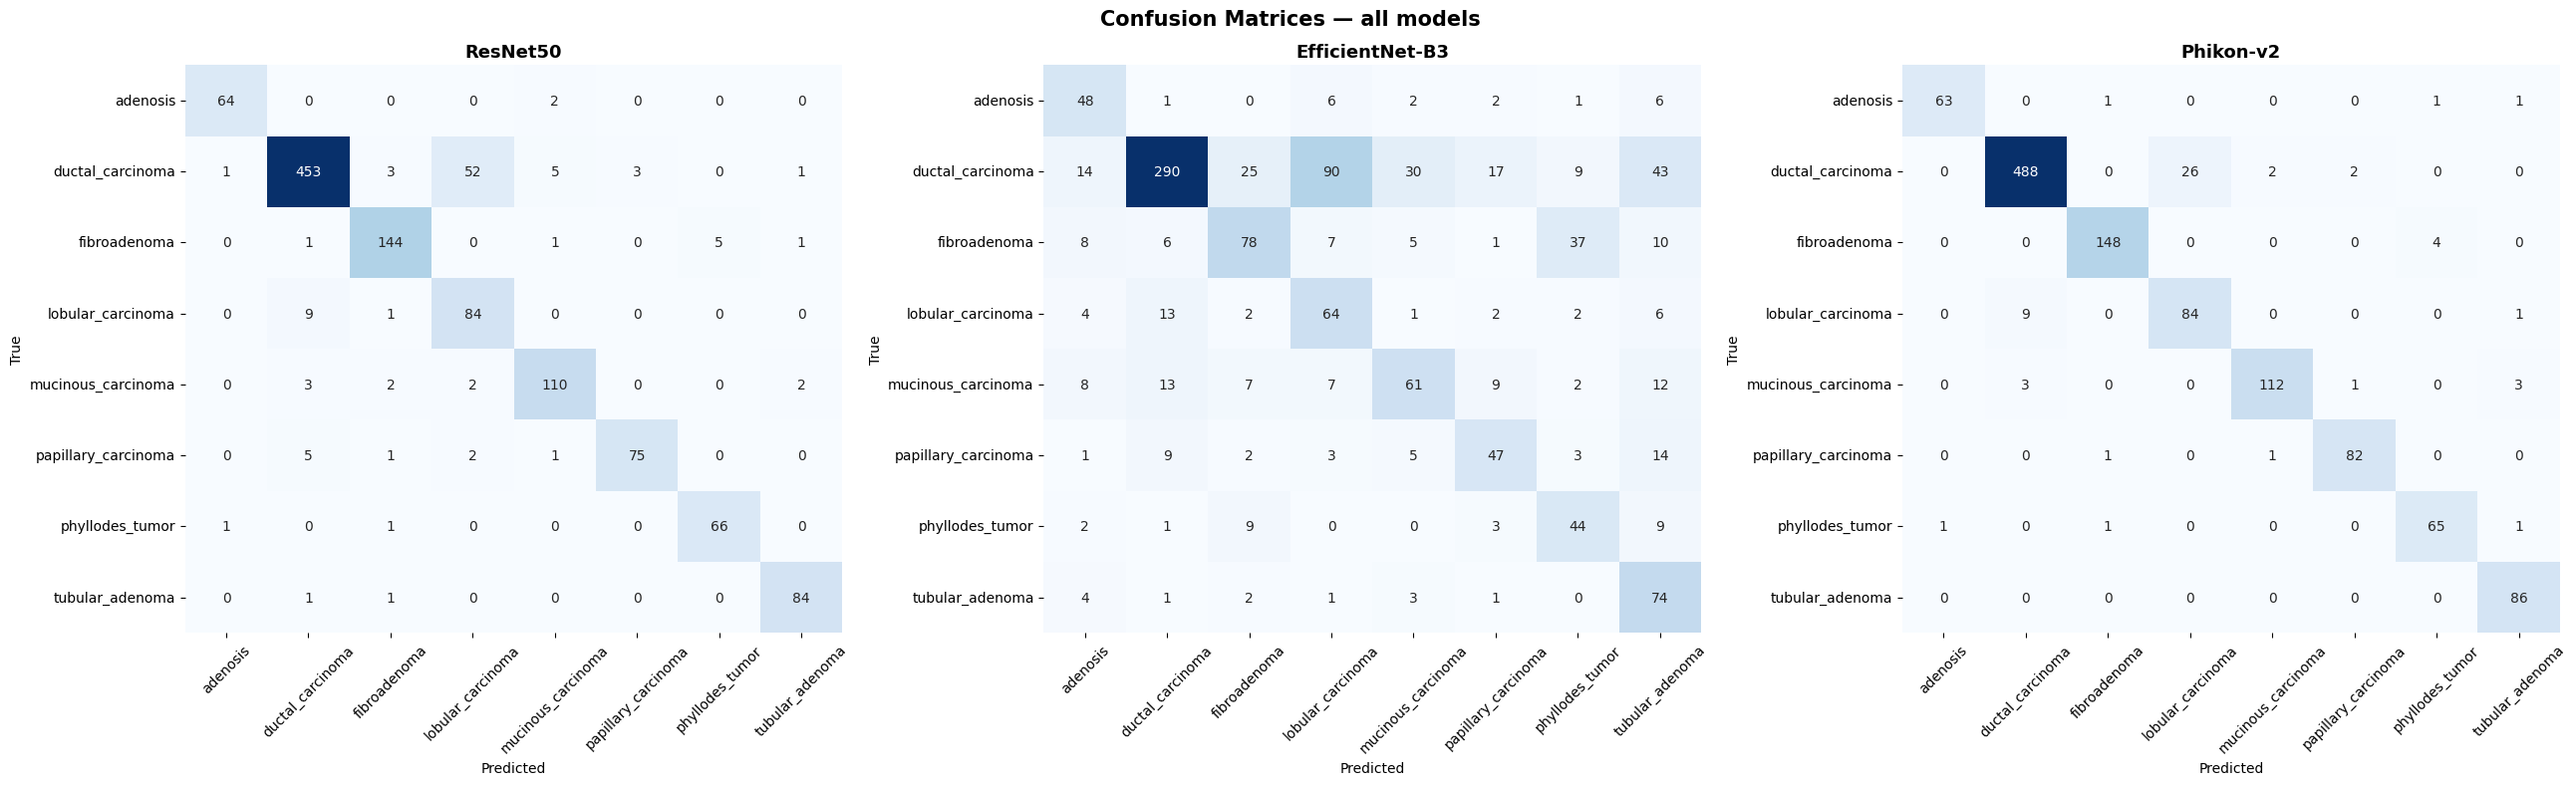

In [22]:
# Cell 21 — confusion matrices for all 3 models
fig, axes = plt.subplots(1, 3, figsize=(26, 8))

for ax, (title, labels, preds) in zip(axes, [
    ('ResNet50',       resnet_labels, resnet_preds),
    ('EfficientNet-B3', eff_labels,   eff_preds),
    ('Phikon-v2',      ph_labels,     ph_preds),
]):
    cm = confusion_matrix(labels, preds)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                xticklabels=class_names, yticklabels=class_names,
                cmap='Blues', cbar=False)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Confusion Matrices — all models', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/figures/confusion_matrices_all.png', dpi=150, bbox_inches='tight')
plt.show()

---
## MAGNIFICATION STUDY

Evaluate best model performance broken down by magnification level (40X, 100X, 200X, 400X).
This is the unique contribution of this notebook.

In [23]:
# Cell 22 — magnification study (best model)
# Use the model with the highest macro F1 from the comparison above
best_f1_val = max(resnet_f1, eff_f1, ph_f1)
if best_f1_val == ph_f1:
    best_model      = phikon_model
    best_loader_fn  = lambda df: DataLoader(
        PhikonDataset(df, phikon_processor), batch_size=16, shuffle=False, num_workers=2)
    is_phikon = True
elif best_f1_val == eff_f1:
    best_model      = eff_model
    best_loader_fn  = lambda df: DataLoader(
        BreakHisDataset(df, val_transform), batch_size=32, shuffle=False, num_workers=2)
    is_phikon = False
else:
    best_model      = resnet_model
    best_loader_fn  = lambda df: DataLoader(
        BreakHisDataset(df, val_transform), batch_size=32, shuffle=False, num_workers=2)
    is_phikon = False

MAGS       = ['40X', '100X', '200X', '400X']
mag_results = {}

for mag in MAGS:
    subset = test_df[test_df['magnification'] == mag].reset_index(drop=True)
    if len(subset) == 0:
        print(f"{mag}: no samples")
        continue
    loader = best_loader_fn(subset)
    labels, preds, f1, acc = evaluate_model(
        best_model, loader, f'Magnification {mag}', phikon=is_phikon)
    mag_results[mag] = {'f1': f1, 'acc': acc, 'n': len(subset)}

print("\n" + "="*45)
print("MAGNIFICATION STUDY SUMMARY")
print(f"{'Magnification':<14} {'N':>5} {'Accuracy':>10} {'Macro F1':>10}")
print("-"*45)
for mag in MAGS:
    if mag in mag_results:
        r = mag_results[mag]
        print(f"{mag:<14} {r['n']:>5} {r['acc']:>10.4f} {r['f1']:>10.4f}")
print("="*45)


=== Magnification 40X ===
Accuracy: 0.9651 | Macro F1: 0.9576
                     precision    recall  f1-score   support

           adenosis     1.0000    1.0000    1.0000        19
   ductal_carcinoma     0.9851    0.9635    0.9742       137
       fibroadenoma     1.0000    0.9722    0.9859        36
  lobular_carcinoma     0.8148    0.9167    0.8627        24
 mucinous_carcinoma     1.0000    0.9444    0.9714        36
papillary_carcinoma     1.0000    1.0000    1.0000        25
    phyllodes_tumor     0.9231    0.9231    0.9231        13
    tubular_adenoma     0.8929    1.0000    0.9434        25

           accuracy                         0.9651       315
          macro avg     0.9520    0.9650    0.9576       315
       weighted avg     0.9677    0.9651    0.9658       315


=== Magnification 100X ===
Accuracy: 0.9485 | Macro F1: 0.9454
                     precision    recall  f1-score   support

           adenosis     1.0000    0.8824    0.9375        17
   ductal_carci

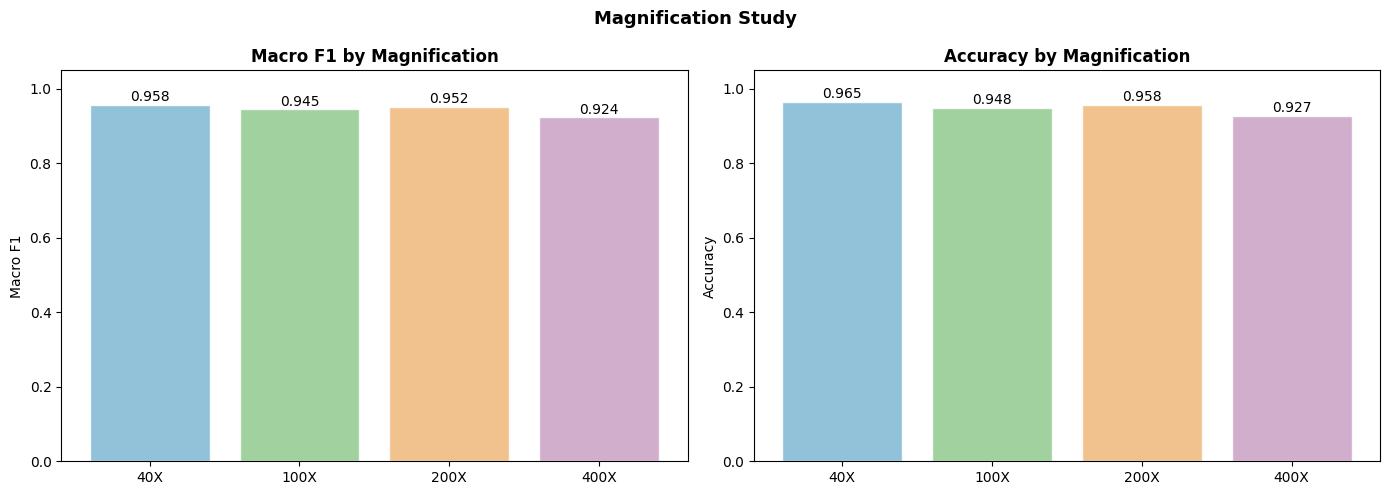

In [24]:
# Cell 23 — magnification visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#7EB8D4', '#8FC98D', '#F0B87A', '#C9A0C4']
mags   = [m for m in MAGS if m in mag_results]
f1s    = [mag_results[m]['f1']  for m in mags]
accs   = [mag_results[m]['acc'] for m in mags]
ns     = [mag_results[m]['n']   for m in mags]

axes[0].bar(mags, f1s,  color=colors, alpha=0.85, edgecolor='white')
axes[0].set_ylim(0, 1.05)
axes[0].set_title('Macro F1 by Magnification', fontweight='bold')
axes[0].set_ylabel('Macro F1')
for i, v in enumerate(f1s):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=10)

axes[1].bar(mags, accs, color=colors, alpha=0.85, edgecolor='white')
axes[1].set_ylim(0, 1.05)
axes[1].set_title('Accuracy by Magnification', fontweight='bold')
axes[1].set_ylabel('Accuracy')
for i, v in enumerate(accs):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=10)

plt.suptitle('Magnification Study', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/figures/magnification_study.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
# Cell 24 — save best checkpoint for Notebook 4 (GradCAM)
import shutil

if is_phikon:
    src  = '/kaggle/working/checkpoints/best_phikon_head.pth'
    name = 'best-checkpoint-multiclass-fixes'
else:
    src  = f'/kaggle/working/checkpoints/best_{"efficientnet_multiclass_fixed" if best_f1_val == eff_f1 else "resnet_multiclass_fixed"}.pth'
    name = 'best-checkpoint-multiclass-fixes'

dest = f'/kaggle/working/checkpoints/{name}.pth'
if src != dest:
    shutil.copy(src, dest)

print(f"Checkpoint: {dest}")
print(f"Size: {os.path.getsize(dest)/1e6:.1f} MB")
print(f"Best model: {best_model_name}")
print("\nNotebook 3 complete. Commit to pass model to Notebook 4 (GradCAM).")

Checkpoint: /kaggle/working/checkpoints/best-checkpoint-multiclass-fixes.pth
Size: 1.1 MB
Best model: Phikon-v2

Notebook 3 complete. Commit to pass model to Notebook 4 (GradCAM).
